In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import numpy as np

Recreate the following image
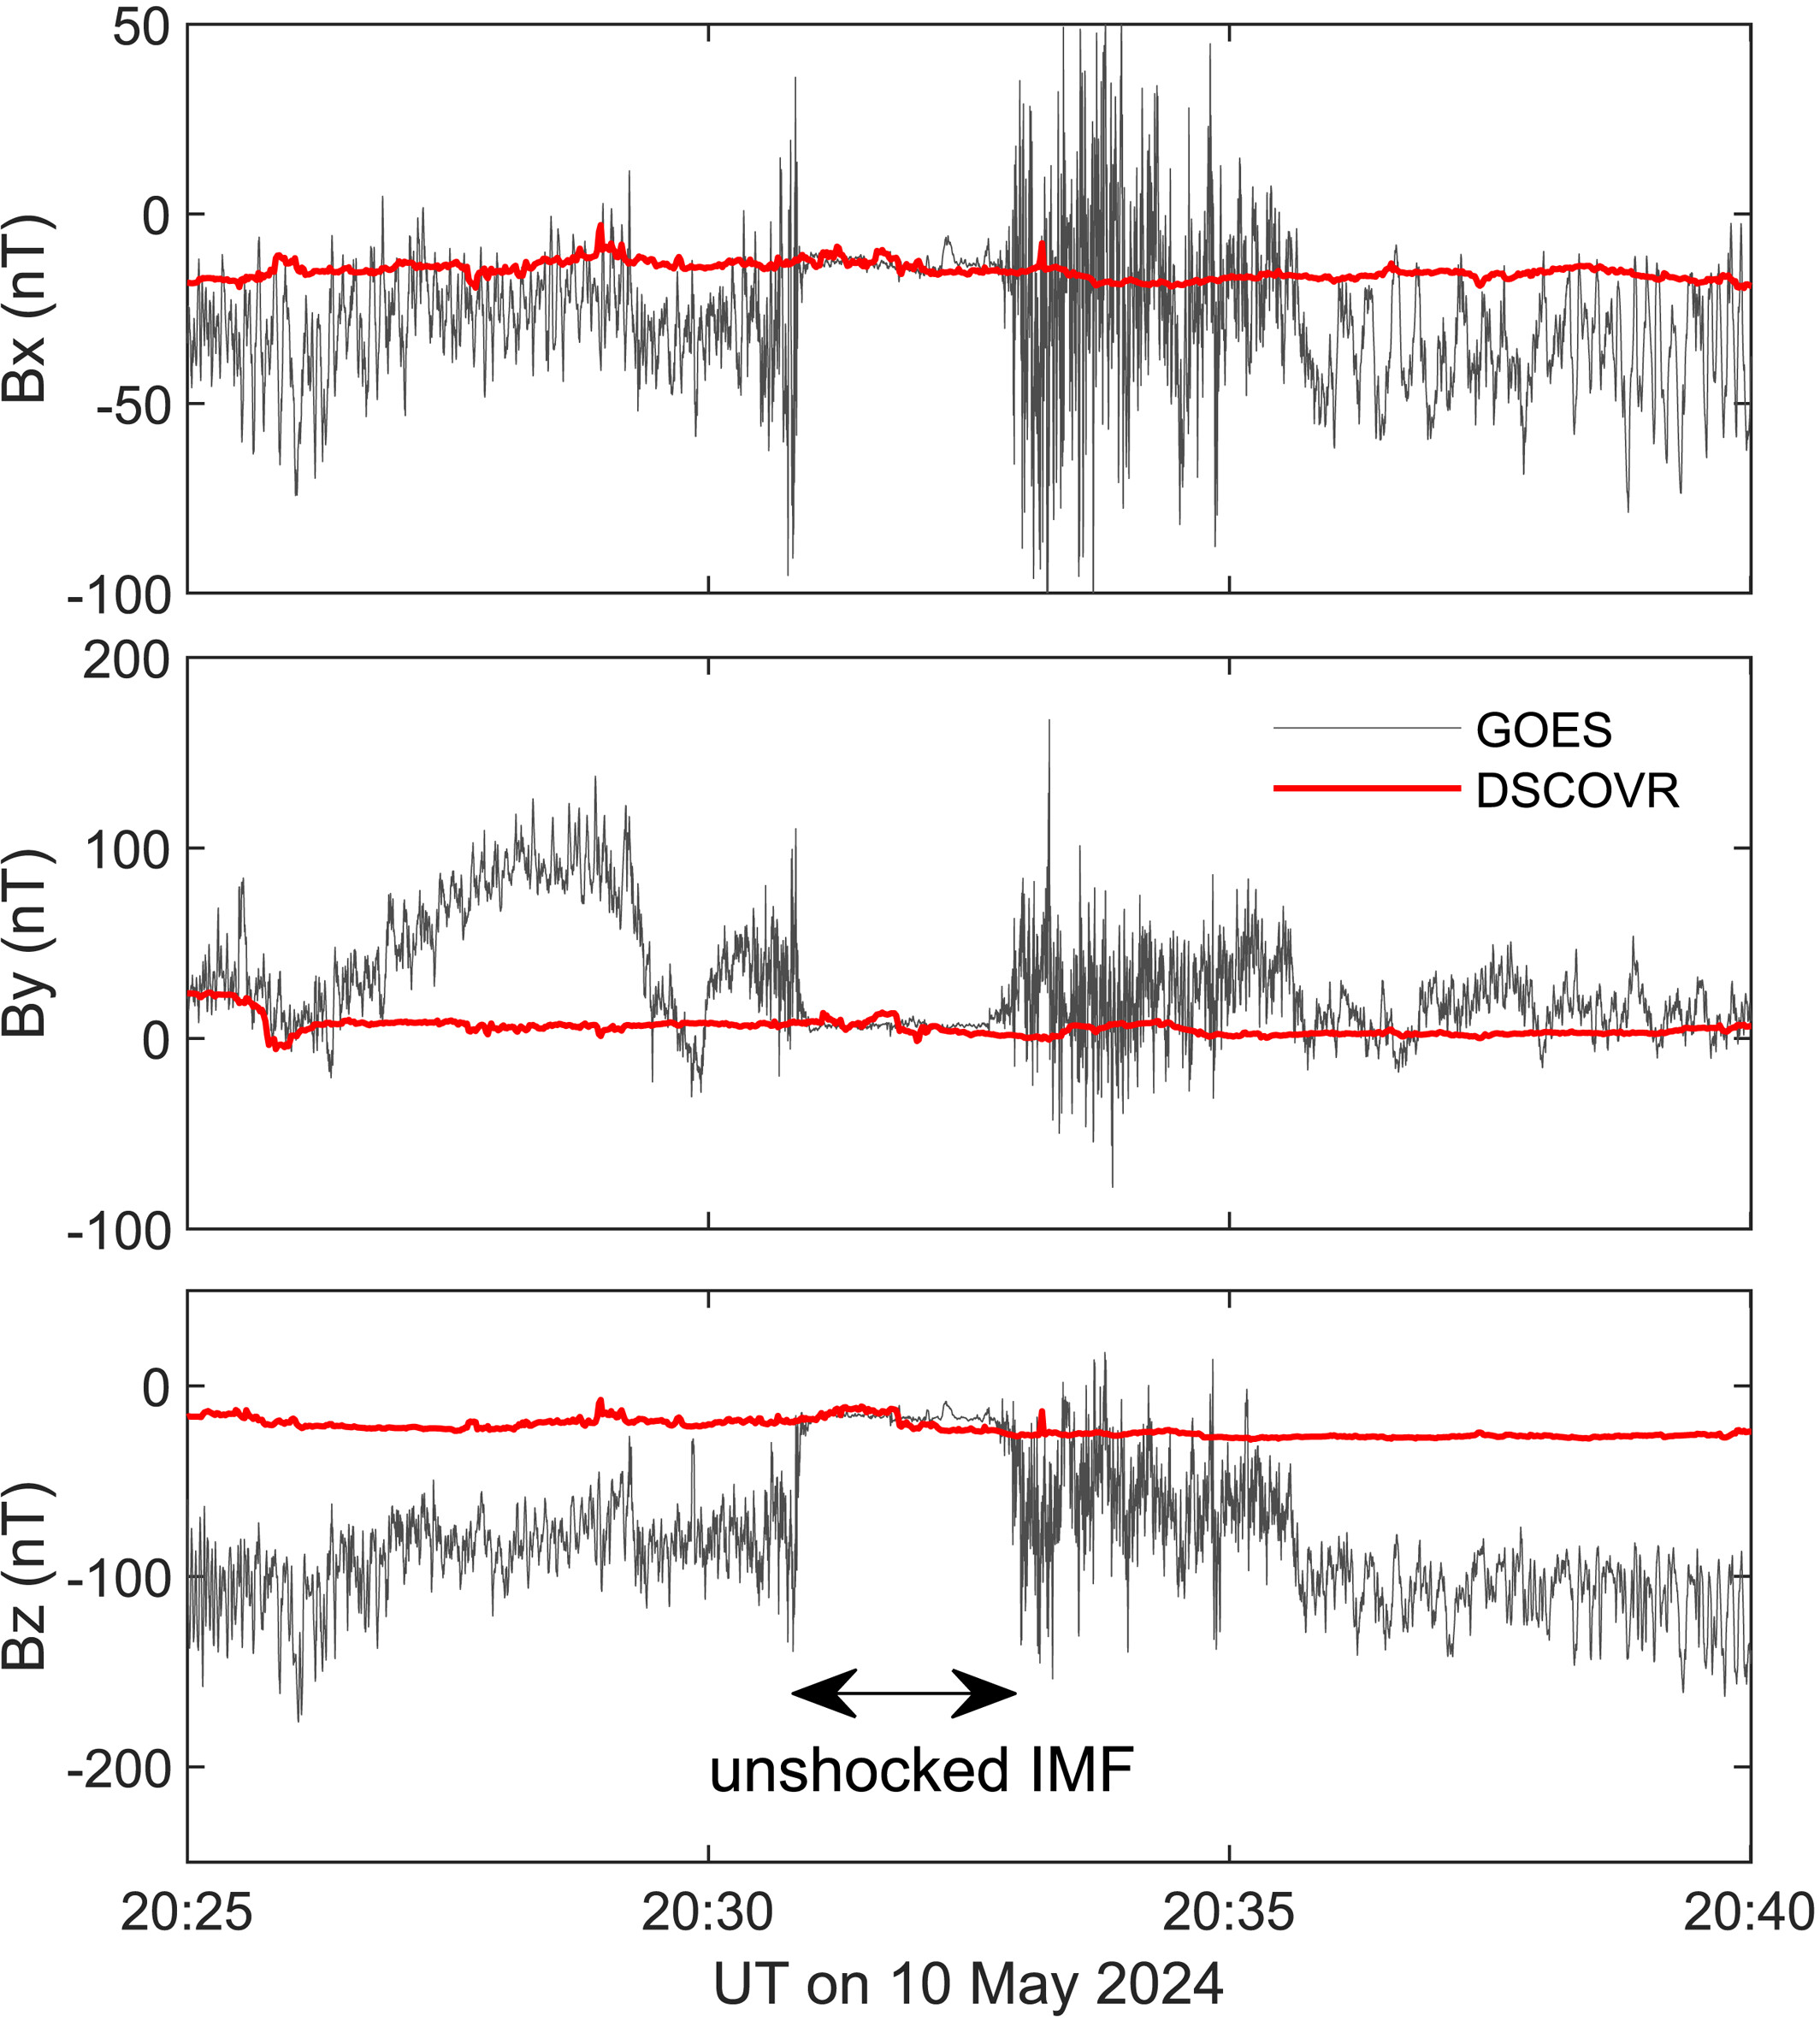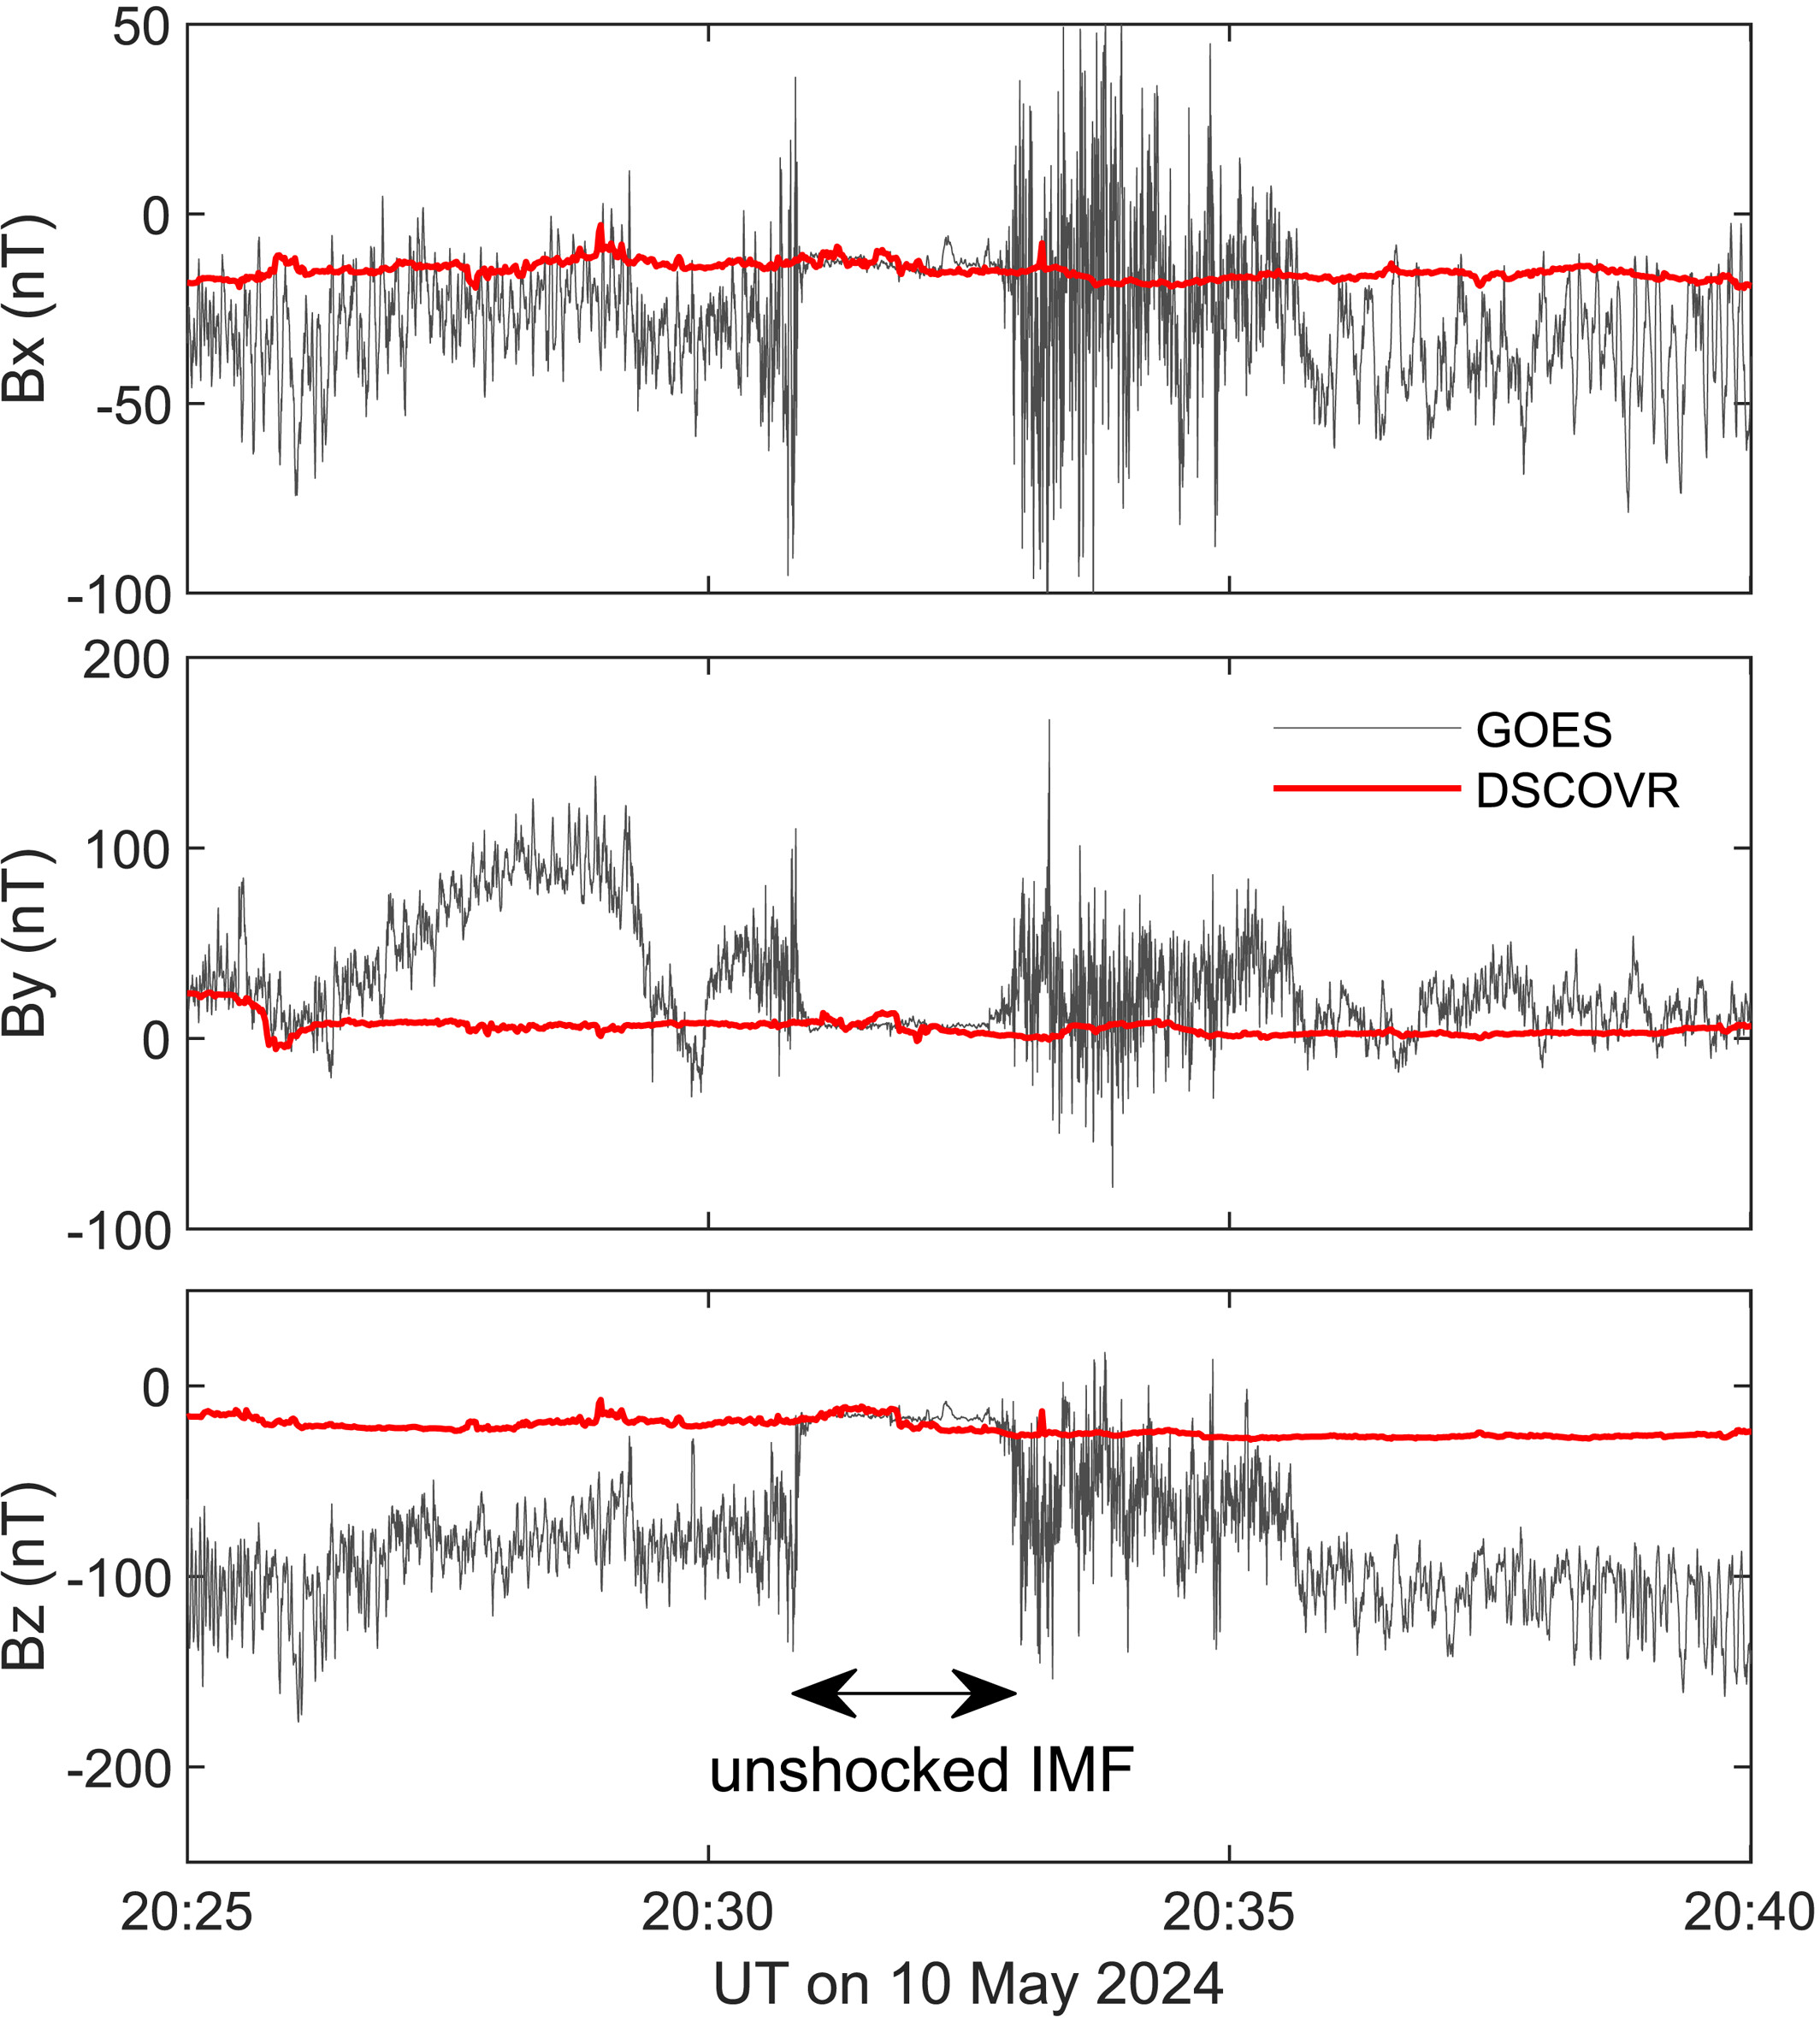

In [2]:
goes_ds = xr.open_dataset('../data/GOES18_data/may_10/ops_mag-l1b-flat_g18_d20240510_v0-0-0.nc')
goes_ds

<xarray.Dataset> Size: 315MB
Dimensions:                                  (sample_number: 864000,
                                              coordinate: 3,
                                              report_number: 86400,
                                              number_of_sensors: 2,
                                              solar_array_current_channel_index: 4,
                                              input_file: 1440,
                                              number_of_time_bounds: 2)
Dimensions without coordinates: sample_number, coordinate, report_number,
                                number_of_sensors,
                                solar_array_current_channel_index, input_file,
                                number_of_time_bounds
Data variables: (12/55)
    IB_data_uncorrected                      (sample_number, coordinate) float32 10MB ...
    OB_data_uncorrected                      (sample_number, coordinate) float32 10MB ...
    IB_mag_ACRF_uncorrected                  (sample_number, coordinate) float32 10MB ...
    OB_mag_ACRF_uncorrected                  (sample_number, coordinate) float32 10MB ...
    IB_mag_BRF_uncorrected                   (sample_number, coordinate) float32 10MB ...
    OB_mag_BRF_uncorrected                   (sample_number, coordinate) float32 10MB ...
    ...                                       ...
    solar_array_current                      (report_number, solar_array_current_channel_index) float32 1MB ...
    product_time                             (input_file, number_of_time_bounds) datetime64[ns] 23kB ...
    sensor_label                             (number_of_sensors) |S20 40B ...
    coordinate_label                         (coordinate) |S1 3B ...
    solar_array_current_channel_index_label  (solar_array_current_channel_index) |S25 100B ...
    percent_uncorrectable_L0_errors          (input_file) float32 6kB ...
Attributes: (12/37)
    production_site:               RBU
    naming_authority:              gov.nesdis.noaa
    institution:                   DOC/NOAA/NESDIS> U.S. Department of Commer...
    project:                       GOES
    iso_series_metadata_id:        f5816f50-fd6d-11e3-a3ac-0800200c9a66
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    ...                            ...
    input_file_count:              1440
    publisher_name:                NOAA's National Centers for Environmental ...
    publisher_type:                institution
    publisher_url:                 https://www.ncei.noaa.gov/
    Conventions:                   CF-1.6, ACDD-1.3
    dataset_name:                  ops_mag-l1b-flat_g18_d20240510_v0-0-0.nc

In [3]:
dscovr_ds = xr.open_dataset('../data/DSCOVR_data/may_10/oe_m1s_dscovr_s20240510000000_e20240510235959_p20240511034110_pub.nc')
dscovr_ds

<xarray.Dataset> Size: 6MB
Dimensions:                   (time: 86400)
Coordinates:
  * time                      (time) datetime64[ns] 691kB 2024-05-10 ... 2024...
Data variables: (12/23)
    sample_count              (time) int16 173kB ...
    measurement_mode          (time) int8 86kB ...
    measurement_range         (time) int8 86kB ...
    bt                        (time) float32 346kB ...
    bx_gse                    (time) float32 346kB ...
    by_gse                    (time) float32 346kB ...
    ...                        ...
    fill_flag                 (time) int8 86kB ...
    possible_saturation_flag  (time) int8 86kB ...
    calibration_mode_flag     (time) int8 86kB ...
    maneuver_flag             (time) int8 86kB ...
    low_sample_count_flag     (time) int8 86kB ...
    overall_quality           (time) int8 86kB ...
Attributes: (12/42)
    Conventions:                    ACDD-1.3, Spase v2.2.3
    title:                          DSCOVR Magnetometer Level 2 One Second Av...
    id:                             oe_m1s_dscovr_s20240510000000_e2024051023...
    naming_authority:               gov.noaa.swpc
    program:                        DSCOVR
    summary:                        Interplanetary magnetic field observation...
    ...                             ...
    publisher_url:                  http://www.ngdc.noaa.gov/dscovr/
    records_maximum:                86400
    records_present:                86400
    records_data:                   85037
    records_fill:                   1363
    records_missing:                0

In [4]:
print(goes_ds['coordinate_label'].values)

[b'x' b'y' b'z']


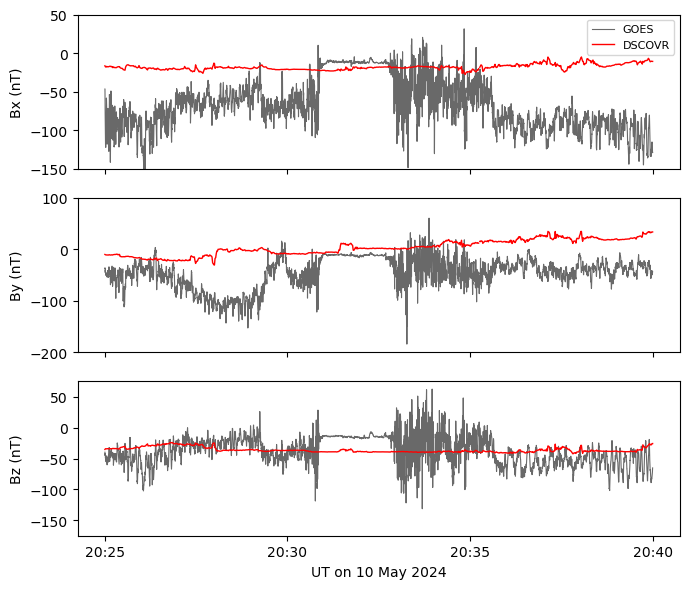

In [7]:
# 1. Prep: Assign decoded labels to GOES coordinates
labels = [label.decode() for label in goes_ds['coordinate_label'].values]
goes_ds = goes_ds.assign_coords(coordinate=('coordinate', labels))

# 2. Extract time and field components
goes_time = goes_ds['OB_time'].values
goes_bx = goes_ds['OB_data_uncorrected'].sel(coordinate='x').values
goes_by = goes_ds['OB_data_uncorrected'].sel(coordinate='y').values
goes_bz = goes_ds['OB_data_uncorrected'].sel(coordinate='z').values

dscovr_time = dscovr_ds['time'].values
dscovr_bx = dscovr_ds['bx_gsm'].values
dscovr_by = dscovr_ds['by_gsm'].values
dscovr_bz = dscovr_ds['bz_gsm'].values

# 3. Mask data to focus on 20:25–20:40 UT
start = np.datetime64('2024-05-10T20:25')
end = np.datetime64('2024-05-10T20:40')
goes_mask = (goes_time >= start) & (goes_time <= end)
dscovr_mask = (dscovr_time >= start) & (dscovr_time <= end)

# 4. Create 3-panel plot with formatting
fig, axs = plt.subplots(3, 1, figsize=(7, 6), sharex=True)

# Bx
axs[0].plot(goes_time[goes_mask], goes_bx[goes_mask], color='dimgray', linewidth=0.8, label='GOES')
axs[0].plot(dscovr_time[dscovr_mask], dscovr_bx[dscovr_mask], color='red', linewidth=1.0, label='DSCOVR')
axs[0].set_ylabel('Bx (nT)')
axs[0].legend(loc='upper right', fontsize=8)
axs[0].set_ylim(-150, 50)
axs[0].yaxis.set_major_locator(ticker.MultipleLocator(50))

# By
axs[1].plot(goes_time[goes_mask], goes_by[goes_mask], color='dimgray', linewidth=0.8)
axs[1].plot(dscovr_time[dscovr_mask], dscovr_by[dscovr_mask], color='red', linewidth=1.0)
axs[1].set_ylabel('By (nT)')
axs[1].set_ylim(-200, 100)
axs[1].yaxis.set_major_locator(ticker.MultipleLocator(100))

# Bz
axs[2].plot(goes_time[goes_mask], goes_bz[goes_mask], color='dimgray', linewidth=0.8)
axs[2].plot(dscovr_time[dscovr_mask], dscovr_bz[dscovr_mask], color='red', linewidth=1.0)
axs[2].set_ylabel('Bz (nT)')
axs[2].set_ylim(-175, 75)
axs[2].yaxis.set_major_locator(ticker.MultipleLocator(50))
axs[2].set_xlabel('UT on 10 May 2024')

# Format x-axis time ticks
axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))


plt.tight_layout()
plt.show()